# MNIST ANN training

Notebook này minh họa nhanh luồng train của tab Predict bằng thư mục dataset đã tạo từ `mnist_dataset.ipynb`. Nó đọc dữ liệu raw để minh họa và đọc dữ liệu normalized để train.

Code được tách thành ba file backend:
- `digits_dataset.py`: tải và xử lý dữ liệu.
- `digits_models.py`: cấu hình và khởi tạo model.
- `train_digits_models.py`: quy trình train và export artifact.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'gk' / 'web' / 'backend').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT)) if str(PROJECT_ROOT) not in sys.path else None

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from gk.web.backend.digits_config import DATASET_DIR, PIXEL_COUNT, PIXEL_SIZE
from gk.web.backend.digits_models import MODEL_CONFIGS, build_logistic, build_mlp

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(PROJECT_ROOT)

/Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02


## 1. Dataset và preprocessing

Notebook này không tải lại dữ liệu và không normalize lại. Nó đọc `mnist_raw.npz` và `mnist_normalized.npz` do `mnist_dataset.ipynb` tạo. Model chỉ nhận `X_train_pixels` và `X_test_pixels` từ file normalized.

In [2]:
raw_data = np.load(DATASET_DIR / 'mnist_raw.npz')
normalized_data = np.load(DATASET_DIR / 'mnist_normalized.npz')
raw_train, y_train = raw_data['X_train_images'], raw_data['y_train']
raw_test, y_test = raw_data['X_test_images'], raw_data['y_test']
X_train_images = normalized_data['X_train_pixels'].astype(float)
X_test_images = normalized_data['X_test_pixels'].astype(float)
X_train_pixels = X_train_images.reshape(len(X_train_images), -1)
X_test_pixels = X_test_images.reshape(len(X_test_images), -1)

train_indices, validation_indices = train_test_split(
    np.arange(len(y_train)), test_size=0.2, stratify=y_train, random_state=RANDOM_SEED + 1
)
scaler = StandardScaler().fit(X_train_pixels[train_indices])
X_fit = scaler.transform(X_train_pixels[train_indices])
X_validation = scaler.transform(X_train_pixels[validation_indices])
X_test = scaler.transform(X_test_pixels)
y_fit = y_train[train_indices]
y_validation = y_train[validation_indices]

print('dataset directory:', DATASET_DIR)
print('raw:', raw_train.shape, raw_test.shape)
print('processed:', X_train_pixels.shape, X_test_pixels.shape)
print('split:', X_fit.shape, X_validation.shape, X_test.shape)

dataset directory: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/mnist_dataset/16x16
raw: (60000, 28, 28) (10000, 28, 28)
processed: (60000, 256) (10000, 256)
split: (48000, 256) (12000, 256) (10000, 256)


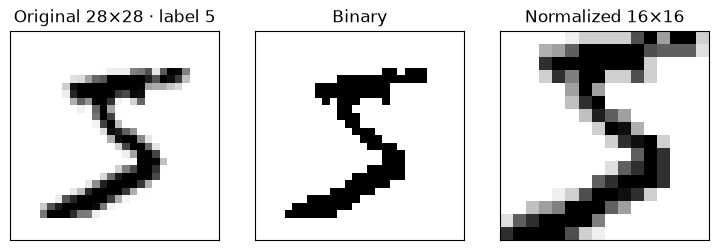

In [3]:
def show_before_after(index: int) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))
    axes[0].imshow(raw_train[index], cmap='gray_r', vmin=0, vmax=255)
    axes[0].set_title(f'Original 28×28 · label {y_train[index]}')
    threshold = max(1.0, float(raw_train[index].max()) * 0.5)
    binary = np.where(raw_train[index] >= threshold, 255, 0)
    axes[1].imshow(binary, cmap='gray_r', vmin=0, vmax=255)
    axes[1].set_title('Binary')
    axes[2].imshow(X_train_pixels[index].reshape(PIXEL_SIZE, PIXEL_SIZE), cmap='gray_r', vmin=0, vmax=1)
    axes[2].set_title(f'Normalized {PIXEL_SIZE}×{PIXEL_SIZE}')
    for axis in axes:
        axis.set_xticks([])
        axis.set_yticks([])
    plt.tight_layout()

show_before_after(0)

## 2. Cấu hình model

Có thể sửa cell này rồi chạy lại các cell train. Hai MLP 4 neuron dùng để minh họa mạng nhỏ; `compact_tuned` dùng mạng có đủ năng lực hơn. Tất cả ANN đều tắt early stopping.

In [4]:
from gk.web.backend.digits_config import (
    DATASET_DIR, DATASET_META_PATH, PIXEL_COUNT, PIXEL_SIZE,
    RAW_DATASET_PATH, SPLIT_PATH,MAX_ITER
)

MODEL_CONFIGS = {
    'logistic': {
        'C': 1.0, 'solver': 'lbfgs', 'max_iter': MAX_ITER,
    },
    'mlp_4_one_layer': {
        'hidden_layer_sizes': (PIXEL_SIZE//2,), 'activation': 'tanh',
        'learning_rate_init': 0.001, 'max_iter': MAX_ITER, 'early_stopping': False,
    },
    'mlp_4_two_layers': {
        'hidden_layer_sizes': (PIXEL_SIZE//2, PIXEL_SIZE//2), 'activation': 'tanh',
        'learning_rate_init': 0.001, 'max_iter': MAX_ITER, 'early_stopping': False,
    },
    'compact_tuned': {
        'hidden_layer_sizes': (PIXEL_SIZE*PIXEL_SIZE//2,), 'activation': 'tanh',
        'hidden_layer_sizes': (PIXEL_SIZE*PIXEL_SIZE//4,), 'activation': 'relu',
        'learning_rate_init': 0.002, 'max_iter': MAX_ITER, 'early_stopping': False,
    },
}

for name, config in MODEL_CONFIGS.items():
    print(name, config)

logistic {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 256}
mlp_4_one_layer {'hidden_layer_sizes': (8,), 'activation': 'tanh', 'learning_rate_init': 0.001, 'max_iter': 256, 'early_stopping': False}
mlp_4_two_layers {'hidden_layer_sizes': (8, 8), 'activation': 'tanh', 'learning_rate_init': 0.001, 'max_iter': 256, 'early_stopping': False}
compact_tuned {'hidden_layer_sizes': (64,), 'activation': 'relu', 'learning_rate_init': 0.002, 'max_iter': 256, 'early_stopping': False}


## 3. Train bốn model

Cell dưới đây train trên toàn bộ `X_fit`. Nếu muốn thử architecture khác, sửa `MODEL_CONFIGS` rồi chạy lại cell.

In [5]:
models = {}

config = MODEL_CONFIGS['logistic']
models['logistic'] = LogisticRegression(
    C=config['C'], solver=config['solver'], max_iter=config['max_iter'], random_state=RANDOM_SEED, verbose=1
).fit(X_fit, y_fit)

for model_id in ('mlp_4_one_layer', 'mlp_4_two_layers', 'compact_tuned'):
    config = MODEL_CONFIGS[model_id]
    models[model_id] = build_mlp(
        config['hidden_layer_sizes'], config['activation'],
        config['learning_rate_init'], config['max_iter'], verbose=True
    ).fit(X_fit, y_fit)

print('trained:', list(models))

Iteration 1, loss = 1.04040794
Validation score: 0.841042
Iteration 2, loss = 0.55866255
Validation score: 0.872083
Iteration 3, loss = 0.46109716
Validation score: 0.883542
Iteration 4, loss = 0.41698729
Validation score: 0.889583
Iteration 5, loss = 0.39339433
Validation score: 0.891875
Iteration 6, loss = 0.37784449
Validation score: 0.894792
Iteration 7, loss = 0.36727579
Validation score: 0.897708
Iteration 8, loss = 0.35919625
Validation score: 0.896667
Iteration 9, loss = 0.35212133
Validation score: 0.899583
Iteration 10, loss = 0.34610339
Validation score: 0.898125
Iteration 11, loss = 0.34159010
Validation score: 0.898750
Iteration 12, loss = 0.33783057
Validation score: 0.900625
Iteration 13, loss = 0.33501566
Validation score: 0.901458
Iteration 14, loss = 0.33139050
Validation score: 0.898542
Iteration 15, loss = 0.32930168
Validation score: 0.902292
Iteration 16, loss = 0.32674450
Validation score: 0.903750
Iteration 17, loss = 0.32548526
Validation score: 0.903125
Iterat

/Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (256) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.60715289
Validation score: 0.860000
Iteration 3, loss = 0.48082584
Validation score: 0.876667
Iteration 4, loss = 0.42159948
Validation score: 0.887500
Iteration 5, loss = 0.38749355
Validation score: 0.889167
Iteration 6, loss = 0.36800221
Validation score: 0.893958
Iteration 7, loss = 0.35223406
Validation score: 0.895833
Iteration 8, loss = 0.34358194
Validation score: 0.898125
Iteration 9, loss = 0.33422986
Validation score: 0.895208
Iteration 10, loss = 0.32774435
Validation score: 0.901250
Iteration 11, loss = 0.32238212
Validation score: 0.903125
Iteration 12, loss = 0.31751275
Validation score: 0.903958
Iteration 13, loss = 0.31287028
Validation score: 0.904167
Iteration 14, loss = 0.30882460
Validation score: 0.903958
Iteration 15, loss = 0.30575017
Validation score: 0.906458
Iteration 16, loss = 0.30318497
Validation score: 0.905208
Iteration 17, loss = 0.30098906
Validation score: 0.910000
Iteration 18, loss = 0.29886341
Validation score: 0.908958
Itera

/Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (256) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32814500
Validation score: 0.942917
Iteration 2, loss = 0.16264671
Validation score: 0.952500
Iteration 3, loss = 0.12687069
Validation score: 0.957917
Iteration 4, loss = 0.10600916
Validation score: 0.957083
Iteration 5, loss = 0.09104644
Validation score: 0.959375
Iteration 6, loss = 0.08064559
Validation score: 0.956250
Iteration 7, loss = 0.06941480
Validation score: 0.956875
Iteration 8, loss = 0.06370569
Validation score: 0.959375
Iteration 9, loss = 0.05724868
Validation score: 0.955833
Iteration 10, loss = 0.05222249
Validation score: 0.955417
Iteration 11, loss = 0.04708440
Validation score: 0.955208
Iteration 12, loss = 0.04200866
Validation score: 0.955000
Iteration 13, loss = 0.03867989
Validation score: 0.955417
Iteration 14, loss = 0.03654375
Validation score: 0.957083
Iteration 15, loss = 0.03180685
Validation score: 0.959375
Iteration 16, loss = 0.03159913
Validation score: 0.960000
Iteration 17, loss = 0.03170919
Validation score: 0.958542
Iterat

/Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (256) reached and the optimization hasn't converged yet.
  warnings.warn(


In [6]:
for model_id, model in models.items():
    validation_accuracy = accuracy_score(y_validation, model.predict(X_validation))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    print(f'{model_id:24} validation={validation_accuracy:.2%} test={test_accuracy:.2%}')

logistic                 validation=90.50% test=91.07%
mlp_4_one_layer          validation=89.76% test=90.47%
mlp_4_two_layers         validation=90.24% test=91.12%
compact_tuned            validation=95.74% test=95.74%


## 4. Quan sát prediction và confusion matrix

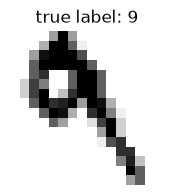

logistic → 4 77.74%
mlp_4_one_layer → 4 83.45%
mlp_4_two_layers → 9 36.33%
compact_tuned → 4 96.79%


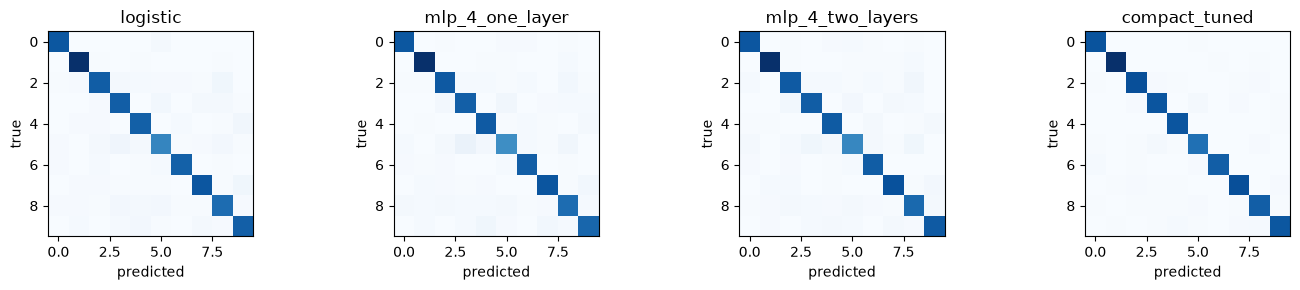

In [7]:
sample_index = 7
plt.figure(figsize=(2, 2))
plt.imshow(X_test_pixels[sample_index].reshape(PIXEL_SIZE, PIXEL_SIZE), cmap='gray_r', vmin=0, vmax=1)
plt.title(f'true label: {y_test[sample_index]}')
plt.axis('off')
plt.show()

for model_id, model in models.items():
    probabilities = model.predict_proba(X_test[sample_index:sample_index + 1])[0]
    print(model_id, '→', int(np.argmax(probabilities)), f'{probabilities.max():.2%}')

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for axis, (model_id, model) in zip(axes, models.items()):
    matrix = confusion_matrix(y_test, model.predict(X_test), labels=np.arange(10))
    axis.imshow(matrix, cmap='Blues')
    axis.set_title(model_id)
    axis.set_xlabel('predicted')
    axis.set_ylabel('true')
plt.tight_layout()

## Ghi chú

Notebook này dùng để học và thử cấu hình. Muốn tạo artifact mà tab web đọc, chạy `python -m gk.web.backend.train_digits_models` để dùng đúng quy trình export production.